# Example: thermal spice fitting
This examples uses UC Merced shading IVs to develop the cell temperature simulation

In [1]:
import os
from pathlib import Path

project_root = Path.cwd().parents[1]
os.chdir(project_root)   # now cwd is .../pvcracks

from pvcracks.pvspice.spice_tools import run_ngspice
from pvcracks.pvspice.spice_tools import ngpsice_read_voltage_current_modules
from pvcracks.pvspice.spice_tools import module_to_netlist

spicepath = "/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice" #kahunaimport numpy as np
import pandas as pd
import pvlib

In [2]:
project_root

PosixPath('/home/nrjost/githome/pvcracks')

In [3]:
ivdata = pd.read_csv("docs/data/IVshaded/Data.csv")
ivdata.dtypes

Date_Time                        object
Irradiance_61                   float64
Voltage                          object
Current                          object
Amb_Temp                        float64
wind_speed                      float64
Observed_Temp of Shaded Cell    float64
Bias_V                            int64
Reverse_Bias_I (Shaded Cell)    float64
Reverse_Bias_V (Shaded Cell)    float64
Shade_Percentage                float64
Middle_Temp                     float64
dtype: object

In [4]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Make a copy so the original dataframe is unchanged
iv = ivdata.copy()

# Parse Date_Time
iv["Date_Time"] = pd.to_datetime(iv["Date_Time"], errors="coerce")

# Function to convert string-list cells into numpy arrays
def parse_array_cell(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.array(x, dtype=float)

    if pd.isna(x):
        return np.array([])

    s = str(x).strip()

    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except Exception:
        # fallback in case literal_eval fails
        s = s.strip("[]")
        return np.fromstring(s, sep=",")

# Convert Voltage and Current columns
iv["Voltage_array"] = iv["Voltage"].apply(parse_array_cell)
iv["Current_array"] = iv["Current"].apply(parse_array_cell)

# Keep only rows where voltage and current arrays are valid and same length
valid = iv.apply(
    lambda row: len(row["Voltage_array"]) == len(row["Current_array"]) and len(row["Voltage_array"]) > 1,
    axis=1
)

iv_valid = iv.loc[valid].copy()

print(f"Valid IV curves: {len(iv_valid)}")
print(f"Invalid IV curves skipped: {len(iv) - len(iv_valid)}")

Valid IV curves: 39
Invalid IV curves skipped: 0


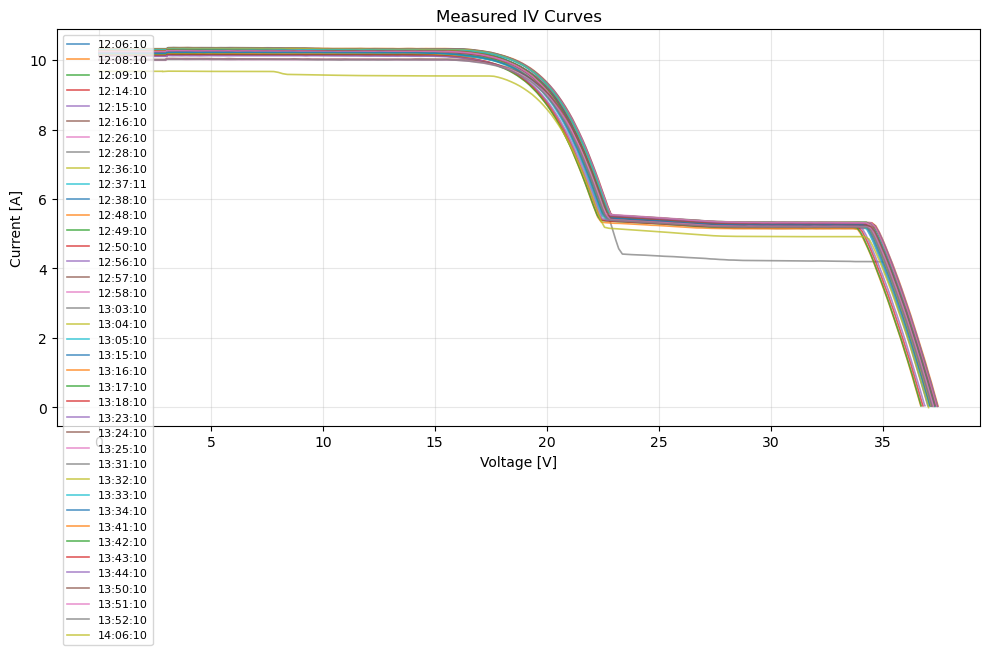

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in iv_valid.iterrows():
    V = row["Voltage_array"]
    I = row["Current_array"]

    ax.plot(
        V,
        I,
        linewidth=1.2,
        alpha=0.75,
        label=row["Date_Time"].strftime("%H:%M:%S") if pd.notna(row["Date_Time"]) else None
    )

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title("Measured IV Curves")
ax.grid(True, alpha=0.3)

# If you have many curves, the legend may be crowded
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [6]:
# Load the CEC module database from pvlib/SAM
cec_modules = pvlib.pvsystem.retrieve_sam("CECMod")

# Your module name
query = "LG320N1K-A5"

# CEC/SAM names often replace "-" with "_" and include manufacturer names
query_norm = query.replace("-", "_").upper()

matches = [
    name for name in cec_modules.columns
    if query_norm in name.upper().replace("-", "_")
]

print("Matches found:")
for m in matches:
    print(m)

# Select the first match
module_name = matches[0]
module_data = cec_modules[module_name]

print("\nSelected module:")
print(module_name)

print("\nModule data:")
print(module_data)

Matches found:
LG_Electronics_Inc__LG320N1K_A5

Selected module:
LG_Electronics_Inc__LG320N1K_A5

Module data:
Technology            Mono-c-Si
Bifacial                      0
STC                     320.346
PTC                       294.7
A_c                       1.649
Length                    1.662
Width                     0.992
N_s                          60
I_sc_ref                  10.19
V_oc_ref                   40.8
I_mp_ref                   9.62
V_mp_ref                   33.3
alpha_sc               0.002038
beta_oc                -0.10608
T_NOCT                     47.7
a_ref                  1.476693
I_L_ref               10.200071
I_o_ref                     0.0
R_s                    0.307043
R_sh_ref              310.65448
Adjust                 4.687218
gamma_r                  -0.357
BIPV                          N
Version       SAM 2018.11.11 r2
Date                   1/3/2019
Name: LG_Electronics_Inc__LG320N1K_A5, dtype: object


In [7]:
# IV fitting:
row_iloc = 0   # choose which IV curve to simulate
row = ivdata.iloc[row_iloc]

N_s = 60
N_modules = 1
N_byp = 2

n_rows = 6
n_cols = 10

# Bottom-left physical cell:
# row 5, col 0, if row 0 is top and col 0 is left
shaded_cell_index = 5 * n_cols + 0

print("Shaded cell index:", shaded_cell_index)

md = module_data.copy()

N_s_cec = int(float(md["N_s"]))
I_sc_ref = float(md["I_sc_ref"])
V_oc_ref = float(md["V_oc_ref"])
I_mp_ref = float(md["I_mp_ref"])
V_mp_ref = float(md["V_mp_ref"])
alpha_sc = float(md["alpha_sc"])
beta_oc = float(md["beta_oc"])
a_ref = float(md["a_ref"])
I_L_ref = float(md["I_L_ref"])
I_o_ref = float(md["I_o_ref"])
R_s_ref = float(md["R_s"])
R_sh_ref = float(md["R_sh_ref"])
Adjust = float(md["Adjust"])

if I_o_ref <= 0 or not np.isfinite(I_o_ref):
    I_o_ref = (I_L_ref - V_oc_ref / R_sh_ref) / np.expm1(V_oc_ref / a_ref)
    print(f"Estimated I_o_ref = {I_o_ref:.4e} A")
else:
    print(f"Using CEC I_o_ref = {I_o_ref:.4e} A")

Shaded cell index: 50
Using CEC I_o_ref = 1.0086e-11 A


In [8]:
G_unshaded = float(row["Irradiance_61"])

shade_pct = float(row["Shade_Percentage"])
shade_frac = np.clip(shade_pct / 100.0, 0.0, 1.0)

# If Shade_Percentage = 49, shaded cell gets 51% irradiance
G_shaded = G_unshaded * (1.0 - shade_frac)

# Use Middle_Temp for most cells
T_unshaded = float(row["Middle_Temp"])

# Use observed shaded cell temperature for the shaded cell
T_shaded = float(row["Observed_Temp of Shaded Cell"])

print("Date_Time:", row["Date_Time"])
print("Unshaded irradiance:", G_unshaded)
print("Shaded irradiance:", G_shaded)
print("Shade percentage:", shade_pct)
print("Unshaded cell temp:", T_unshaded)
print("Shaded cell temp:", T_shaded)

Date_Time: 2025-09-14T12:06:10
Unshaded irradiance: 989.21
Shaded irradiance: 504.49710000000005
Shade percentage: 49.0
Unshaded cell temp: 44.11791
Shaded cell temp: 82.4


In [9]:
IL_unshaded, I0_unshaded, Rs_module_unshaded, Rsh_module_unshaded, nNsVth_unshaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=G_unshaded,
    temp_cell=T_unshaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [10]:
IL_shaded, I0_shaded, Rs_module_shaded, Rsh_module_shaded, nNsVth_shaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=max(G_shaded, 1e-6),
    temp_cell=T_shaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [11]:
sd_unshaded = pvlib.pvsystem.singlediode(
    photocurrent=IL_unshaded,
    saturation_current=I0_unshaded,
    resistance_series=Rs_module_unshaded,
    resistance_shunt=Rsh_module_unshaded,
    nNsVth=nNsVth_unshaded,
)

v_oc_sim = float(sd_unshaded["v_oc"])

print("Estimated unshaded module Voc:", v_oc_sim)

Estimated unshaded module Voc: 38.6518778387981


In [12]:
Rs_cell_unshaded = Rs_module_unshaded / N_s
Rsh_cell_unshaded = Rsh_module_unshaded / N_s

Rs_cell_shaded = Rs_module_shaded / N_s
Rsh_cell_shaded = Rsh_module_shaded / N_s

# Thermal voltage at unshaded cell temperature
k_B = 1.380649e-23
q_e = 1.602176634e-19
T_K = T_unshaded + 273.15
Vth_cell = k_B * T_K / q_e

# SPICE diode ideality factor N
ideality_factor = nNsVth_unshaded / (N_s * Vth_cell)

# Use unshaded saturation current for the common SPICE diode model
saturation_current = I0_unshaded

print("IL unshaded:", IL_unshaded)
print("IL shaded:", IL_shaded)
print("Rs cell unshaded:", Rs_cell_unshaded)
print("Rsh cell unshaded:", Rsh_cell_unshaded)
print("Rsh cell shaded:", Rsh_cell_shaded)
print("SPICE ideality factor:", ideality_factor)
print("SPICE saturation current:", saturation_current)

IL unshaded: 10.126747588516295
IL shaded: 5.202156675180904
Rs cell unshaded: 0.005117383333333334
Rsh cell unshaded: 5.234050066888392
Rsh cell shaded: 10.26284326840861
SPICE ideality factor: 0.9579244607561156
SPICE saturation current: 2.0780120598826555e-10


In [13]:
cell_currents = np.full(N_s, IL_unshaded, dtype=float)
series_resistances = np.full(N_s, Rs_cell_unshaded, dtype=float)
shunt_resistances = np.full(N_s, Rsh_cell_unshaded, dtype=float)

# Apply shade to bottom-left cell
cell_currents[shaded_cell_index] = IL_shaded
series_resistances[shaded_cell_index] = Rs_cell_shaded
shunt_resistances[shaded_cell_index] = Rsh_cell_shaded

print("Cell photocurrent array:")
print(cell_currents)

Cell photocurrent array:
[10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759  5.20215668 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759]


In [15]:
spice_path = "docs/data/IVshaded"

breakdown_voltage = 12.0

# In module_to_netlist, v_bypass is used as BV in:
# .model sdby D (IS=1e-7 N=1 BV={v_bypass} IBV=20)
# So this is the reverse breakdown voltage of the bypass diode model.
v_bypass = 100.0

circuit_content, halfcut = module_to_netlist(
    path=spice_path,
    N_s=N_s,
    cell_currents=cell_currents,
    series_resistances=series_resistances,
    shunt_resistances=shunt_resistances,
    ideality_factor=ideality_factor,
    saturation_current=saturation_current,
    breakdown_voltage=breakdown_voltage,
    v_bypass=v_bypass,
    v_oc=v_oc_sim,
    TNOM=T_unshaded,
    circuit_name="solar_circuit",
)

print("halfcut:", halfcut)

All series interconnection of 60 solar cells
halfcut: False


In [17]:
circuit_file = os.path.join(spice_path, "solar_circuit.cir")

run_ngspice(
    ngpsice_path=spicepath,
    circuit_file=circuit_file,
)


Note: No compatibility mode selected!


Circuit: 

Doing analysis at TEMP = 44.117910 and TNOM = 44.117910


No. of Data Rows : 397
ASCII raw file "docs/data/IVshaded/solar_circuit.out"
ASCII raw file "docs/data/IVshaded/solar_circuit.txt"
ngspice-41 done


Note: v1: has no value, DC 0 assumed

Error: no such function as i,
    or i(d1) is not available.


In [18]:
voltage_spice, current_spice, df_spice = ngpsice_read_voltage_current_modules(spice_path)

# Depending on ngspice sign convention, source current may be negative.
# Flip so current is positive like your measured IV curves.
if len(df_spice) > 0 and np.nanmedian(df_spice["I"]) < 0:
    df_spice["I"] = -df_spice["I"]

df_spice.head()

,V,I
0,0.0,10.114580
1,0.1,10.114103
2,0.2,10.113625
3,0.3,10.113148
4,0.4,10.112671


In [19]:
if isinstance(row["Voltage"], str):
    V_meas = np.asarray(ast.literal_eval(row["Voltage"]), dtype=float)
else:
    V_meas = np.asarray(row["Voltage"], dtype=float)

if isinstance(row["Current"], str):
    I_meas = np.asarray(ast.literal_eval(row["Current"]), dtype=float)
else:
    I_meas = np.asarray(row["Current"], dtype=float)

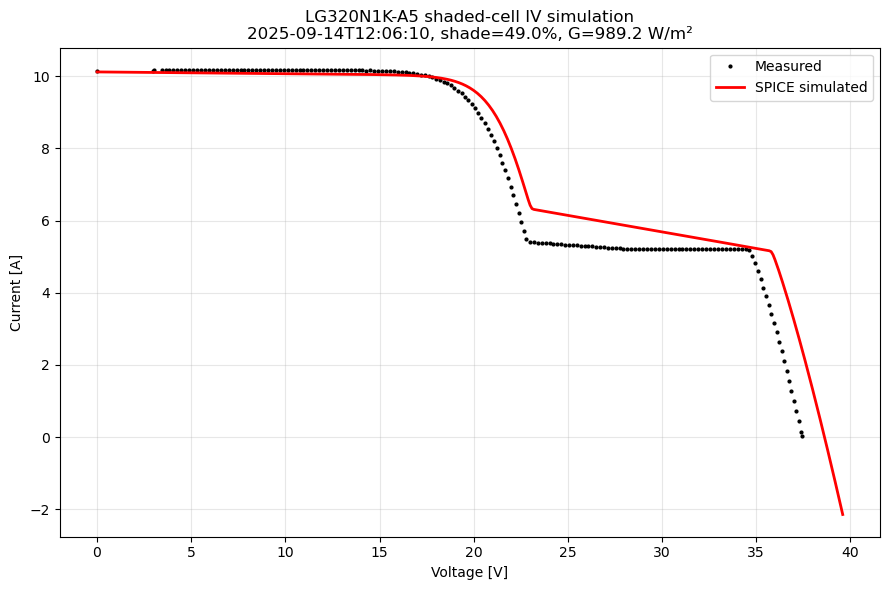

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    V_meas,
    I_meas,
    "k.",
    markersize=4,
    label="Measured",
)

ax.plot(
    df_spice["V"],
    df_spice["I"],
    "r-",
    linewidth=2,
    label="SPICE simulated",
)

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title(
    f"LG320N1K-A5 shaded-cell IV simulation\n"
    f"{row['Date_Time']}, shade={shade_pct:.1f}%, "
    f"G={G_unshaded:.1f} W/m²"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()